# Imports

In [30]:
import pandas as pd
import numpy as np
import sys
import os
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)
from sklearn.model_selection import train_test_split
from Autoencoder import Autoencoder 
import matplotlib.pyplot as plt

# Data preparetion

In [31]:
data = pd.read_csv('../data/data.csv')
data.drop(columns=['diagnosis', 'id','Unnamed: 32'], inplace=True, errors='ignore')
print(data.head())


   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [32]:
x_train , x_temp= train_test_split(data, test_size = 0.299, random_state=42)
x_val, x_test = train_test_split(x_temp, test_size = 0.5, random_state=42)
print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")

Train shape: (398, 30), Validation shape: (85, 30), Test shape: (86, 30)


### data standardization and normalization


In [33]:
# Standardize for pca kmeans and gmm
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)
x_train_standardized = (x_train - mean) / (std + 1e-8) #add small value to avoid division by zero

In [34]:
# normalized data for autoencoder
min = np.min(x_train, axis=0)
max = np.max(x_train, axis=0)
x_train_normalized = (x_train - min) / (max - min + 1e-8) #add small value to avoid division by zero
x_train_normalized.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
149,0.296244,0.277308,0.283818,0.177894,0.167807,0.151976,0.067502,0.066054,0.163374,0.122999,...,0.243476,0.278252,0.217071,0.124628,0.115640,0.163881,0.173124,0.218396,0.154741,0.128009
124,0.278123,0.225905,0.269406,0.164378,0.085638,0.184474,0.189597,0.139165,0.136145,0.174179,...,0.204006,0.285981,0.190636,0.101355,0.154940,0.242126,0.366172,0.325762,0.095210,0.180061
421,0.342769,0.144403,0.355879,0.208401,0.402319,0.562359,0.339738,0.313121,0.490657,0.507582,...,0.284409,0.168443,0.303035,0.145296,0.364200,0.364306,0.356321,0.402032,0.248768,0.314005
195,0.255595,0.223876,0.243936,0.148460,0.167509,0.117389,0.090745,0.118141,0.353444,0.141323,...,0.190118,0.265991,0.184637,0.093539,0.207437,0.128688,0.195262,0.298803,0.287601,0.122499
545,0.290367,0.457220,0.277183,0.172831,0.296858,0.164680,0.069681,0.121421,0.265350,0.169545,...,0.243842,0.454957,0.219053,0.125595,0.294203,0.129905,0.116117,0.260305,0.212300,0.122838


# Autoencoder


In [35]:
layer_sizes = [30, 20, 15, 10, 15, 20, 30]
activation_functions = ['relu', 'tanh', 'relu', 'relu', 'tanh', 'sigmoid'] 
ae = Autoencoder(layer_sizes, activation_functions)

In [36]:
loss_history = ae.train(x_train_normalized.values,epochs=200)

Epoch 0, Loss: 0.0609, Learning Rate: 0.1000
Epoch 10, Loss: 0.0155, Learning Rate: 0.0909
Epoch 20, Loss: 0.0119, Learning Rate: 0.0833
Epoch 30, Loss: 0.0107, Learning Rate: 0.0769
Epoch 40, Loss: 0.0099, Learning Rate: 0.0714
Epoch 50, Loss: 0.0094, Learning Rate: 0.0667
Epoch 60, Loss: 0.0089, Learning Rate: 0.0625
Epoch 70, Loss: 0.0085, Learning Rate: 0.0588
Epoch 80, Loss: 0.0081, Learning Rate: 0.0556
Epoch 90, Loss: 0.0078, Learning Rate: 0.0526
Epoch 100, Loss: 0.0075, Learning Rate: 0.0500
Epoch 110, Loss: 0.0073, Learning Rate: 0.0476
Epoch 120, Loss: 0.0071, Learning Rate: 0.0455
Epoch 130, Loss: 0.0069, Learning Rate: 0.0435
Epoch 140, Loss: 0.0067, Learning Rate: 0.0417
Epoch 150, Loss: 0.0066, Learning Rate: 0.0400
Epoch 160, Loss: 0.0065, Learning Rate: 0.0385
Epoch 170, Loss: 0.0064, Learning Rate: 0.0370
Epoch 180, Loss: 0.0063, Learning Rate: 0.0357
Epoch 190, Loss: 0.0062, Learning Rate: 0.0345


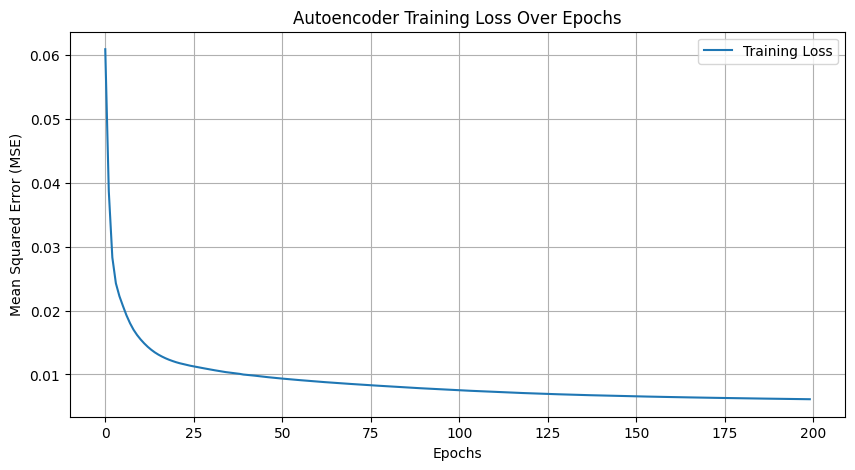

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('Autoencoder Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Encoded data

In [38]:
x_encoded = []
layer_sizes= [[30, 20, 10, 2, 10, 20, 30], [30, 22, 15, 5, 15, 22, 30], [30, 24, 18, 10, 18, 24, 30], [30, 26, 20, 15, 20, 26, 30], [30, 28, 24, 20, 24, 28, 30]]
for size in layer_sizes: 
    activation_functions = ['relu', 'tanh', 'relu', 'relu', 'tanh', 'sigmoid'] 
    ae = Autoencoder(size, activation_functions)
    ae.train(x_train_normalized.values, epochs=200)
    encoded = ae.forward(x_train_normalized.values)
    x_encoded.append(encoded)

Epoch 0, Loss: 0.0494, Learning Rate: 0.1000
Epoch 10, Loss: 0.0156, Learning Rate: 0.0909
Epoch 20, Loss: 0.0139, Learning Rate: 0.0833
Epoch 30, Loss: 0.0132, Learning Rate: 0.0769
Epoch 40, Loss: 0.0127, Learning Rate: 0.0714
Epoch 50, Loss: 0.0124, Learning Rate: 0.0667
Epoch 60, Loss: 0.0122, Learning Rate: 0.0625
Epoch 70, Loss: 0.0120, Learning Rate: 0.0588
Epoch 80, Loss: 0.0119, Learning Rate: 0.0556
Epoch 90, Loss: 0.0118, Learning Rate: 0.0526
Epoch 100, Loss: 0.0118, Learning Rate: 0.0500
Epoch 110, Loss: 0.0117, Learning Rate: 0.0476
Epoch 120, Loss: 0.0117, Learning Rate: 0.0455
Epoch 130, Loss: 0.0116, Learning Rate: 0.0435
Epoch 140, Loss: 0.0116, Learning Rate: 0.0417
Epoch 150, Loss: 0.0116, Learning Rate: 0.0400
Epoch 160, Loss: 0.0116, Learning Rate: 0.0385
Epoch 170, Loss: 0.0115, Learning Rate: 0.0370
Epoch 180, Loss: 0.0115, Learning Rate: 0.0357
Epoch 190, Loss: 0.0115, Learning Rate: 0.0345
Epoch 0, Loss: 0.0442, Learning Rate: 0.1000
Epoch 10, Loss: 0.0170, Le